# A04 Behavior Slices

This notebook localizes RouteRec gains to behavioral regimes and compares gain with routing concentration.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

RESULTS_ROOT = Path("/workspace/FeaturedMoE/writing/results")
if str(RESULTS_ROOT) not in sys.path:
    sys.path.insert(0, str(RESULTS_ROOT))

from _shared.io_helpers import export_figure, load_csv_or_demo
from _shared.paper_theme import set_paper_theme
from _shared.plot_builders import (
    grouped_barplot,
    heatmap_from_long,
    lineplot_with_markers,
    scatterplot_with_annotations,
)

set_paper_theme(context="notebook")

METRICS_PATH = RESULTS_ROOT / "A04_behavior_slices/A04a_slice_metrics.csv"
GAIN_PATH = RESULTS_ROOT / "A04_behavior_slices/A04b_slice_gain_concentration.csv"
METRIC_COLUMNS = [
    "paper_section", "panel", "dataset", "slice_name", "variant_or_model", "metric", "cutoff", "value", "sample_count",
    "split", "selection_rule", "run_id", "source_path", "notes",
]
GAIN_COLUMNS = [
    "paper_section", "panel", "dataset", "slice_name", "variant_or_model", "measure", "value", "split", "selection_rule",
    "run_id", "source_path", "notes",
]


def demo_slice_metrics() -> pd.DataFrame:
    rows = []
    slices = ["repeat-heavy", "fast-tempo", "narrow-focus", "exploration-heavy"]
    values = {
        "RouteRec": [0.079, 0.085, 0.082, 0.076],
        "SASRec": [0.073, 0.079, 0.078, 0.071],
        "BSARec": [0.075, 0.081, 0.079, 0.072],
    }
    for model, scores in values.items():
        for slice_name, value in zip(slices, scores):
            rows.append({
                "paper_section": "A04_behavior_slices",
                "panel": "slice_metrics",
                "dataset": "Beauty",
                "slice_name": slice_name,
                "variant_or_model": model,
                "metric": "MRR",
                "cutoff": 20,
                "value": value,
                "sample_count": 1000,
                "split": "test",
                "selection_rule": "demo",
                "run_id": "demo",
                "source_path": "demo",
                "notes": "demo data",
            })
    return pd.DataFrame(rows)


def demo_slice_gain() -> pd.DataFrame:
    rows = []
    slice_points = {
        "repeat-heavy": (0.71, 0.020),
        "fast-tempo": (0.77, 0.028),
        "narrow-focus": (0.69, 0.017),
        "exploration-heavy": (0.81, 0.031),
    }
    for slice_name, (concentration, relative_gain) in slice_points.items():
        rows.extend(
            [
                {
                    "paper_section": "A04_behavior_slices",
                    "panel": "slice_gain",
                    "dataset": "Beauty",
                    "slice_name": slice_name,
                    "variant_or_model": "RouteRec",
                    "measure": "route_concentration",
                    "value": concentration,
                    "split": "test",
                    "selection_rule": "demo",
                    "run_id": "demo",
                    "source_path": "demo",
                    "notes": "demo data",
                },
                {
                    "paper_section": "A04_behavior_slices",
                    "panel": "slice_gain",
                    "dataset": "Beauty",
                    "slice_name": slice_name,
                    "variant_or_model": "RouteRec",
                    "measure": "relative_gain",
                    "value": relative_gain,
                    "split": "test",
                    "selection_rule": "demo",
                    "run_id": "demo",
                    "source_path": "demo",
                    "notes": "demo data",
                },
            ]
        )
    return pd.DataFrame(rows)


In [2]:
metrics_df, metrics_mode = load_csv_or_demo(METRICS_PATH, METRIC_COLUMNS, demo_builder=demo_slice_metrics)
gain_df, gain_mode = load_csv_or_demo(GAIN_PATH, GAIN_COLUMNS, demo_builder=demo_slice_gain)
display(Markdown(f"**Load mode:** metrics={metrics_mode}, gain={gain_mode}"))


**Load mode:** metrics=demo, gain=demo

Saved figures: /workspace/FeaturedMoE/writing/results/generated_figures/A04_behavior_slices.png, /workspace/FeaturedMoE/writing/results/generated_figures/A04_behavior_slices.pdf

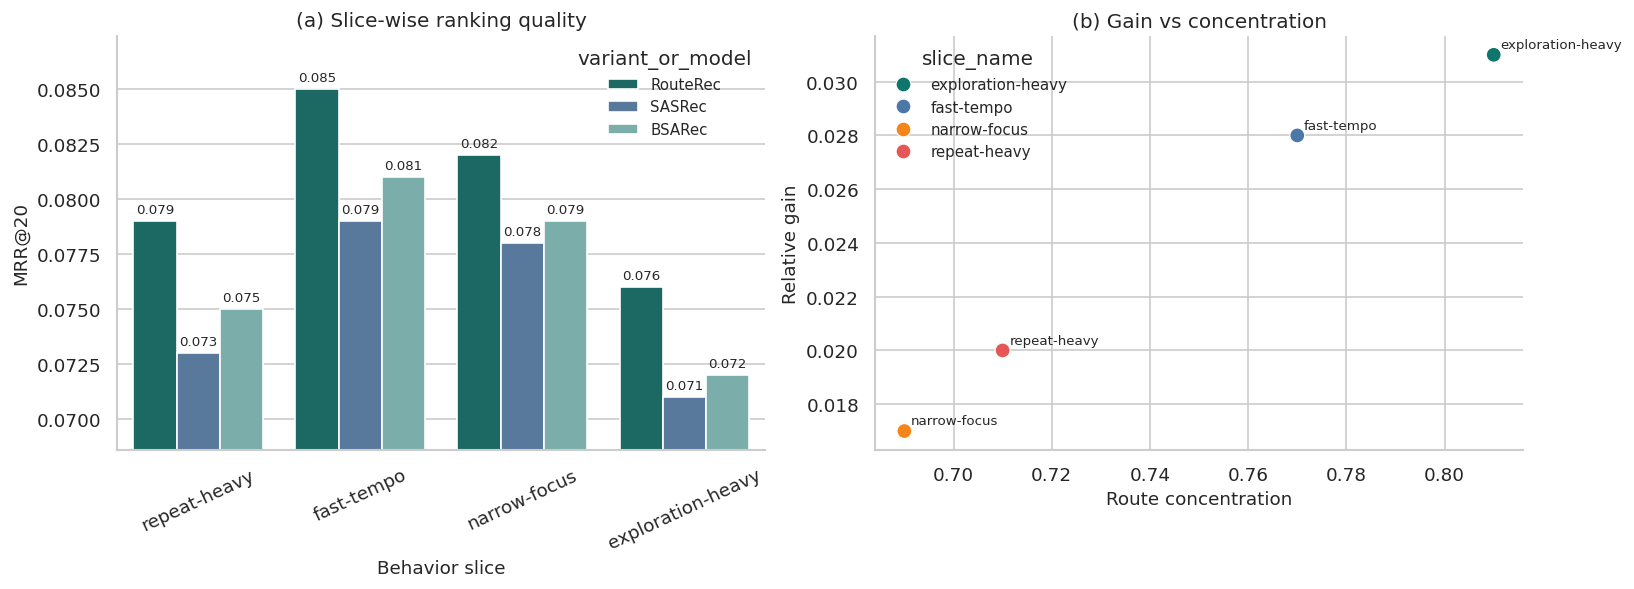

In [3]:
gain_pivot = gain_df.pivot_table(index=["dataset", "slice_name", "variant_or_model"], columns="measure", values="value").reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), constrained_layout=True)
grouped_barplot(metrics_df, x="slice_name", hue="variant_or_model", y="value", ax=axes[0], title="(a) Slice-wise ranking quality", ylabel="MRR@20", xlabel="Behavior slice", rotate=25)
scatterplot_with_annotations(gain_pivot, x="route_concentration", y="relative_gain", hue="slice_name", annotate_column="slice_name", ax=axes[1], title="(b) Gain vs concentration", ylabel="Relative gain", xlabel="Route concentration")
saved_paths = export_figure(fig, "A04_behavior_slices", RESULTS_ROOT)
display(Markdown("Saved figures: " + ", ".join(str(path) for path in saved_paths)))
plt.show()
